<a href="https://colab.research.google.com/github/Nikolai-N484/Data201_NikolaiN/blob/main/Week8/DATA_201_Week_8B_Classification_2_NB_and_LDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## The Stock Market Data

We continue to use the `Smarket`
data, which is part of the `ISLP`
library.

We start by importing  our libraries at this top level; these are all imports we have seen in previous labs.

Install the ISLP package

In [ ]:
pip install ISLP

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 29.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.2/80.2 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 831.6/831.6 kB 30.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 3.3 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=c7ada0c0ea3243c0809900259819830c6b541b97f74dbc36aaef3c8624f1e3d9
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


In [ ]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
import statsmodels.api as sm
from ISLP import load_data
from ISLP.models import (ModelSpec as MS,
                         summarize)

We also collect together the new imports needed for this lab.

In [ ]:
from ISLP import confusion_table
from ISLP.models import contrast
from sklearn.discriminant_analysis import \
     (LinearDiscriminantAnalysis as LDA,
      QuadraticDiscriminantAnalysis as QDA)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix


Now we are ready to load the `Smarket` data.

In [ ]:
Smarket = load_data('Smarket')
Smarket

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,2001,0.381,-0.192,-2.624,-1.055,5.010,1.19130,0.959,Up
1,2001,0.959,0.381,-0.192,-2.624,-1.055,1.29650,1.032,Up
2,2001,1.032,0.959,0.381,-0.192,-2.624,1.41120,-0.623,Down
3,2001,-0.623,1.032,0.959,0.381,-0.192,1.27600,0.614,Up
4,2001,0.614,-0.623,1.032,0.959,0.381,1.20570,0.213,Up
...,...,...,...,...,...,...,...,...,...
1245,2005,0.422,0.252,-0.024,-0.584,-0.285,1.88850,0.043,Up
1246,2005,0.043,0.422,0.252,-0.024,-0.584,1.28581,-0.955,Down
1247,2005,-0.955,0.043,0.422,0.252,-0.024,1.54047,0.130,Up
1248,2005,0.130,-0.955,0.043,0.422,0.252,1.42236,-0.298,Down


This gives a truncated listing of the data.
We can see what the variable names are.

In [ ]:
Smarket.columns

Index(['Year', 'Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5', 'Volume', 'Today',
       'Direction'],
      dtype='object')

## Logistic Regression
Here's the model we previously fit using a train/test split based on 2001-2004 versus 2005.

In [ ]:
#Define the Boolean variable to identify years 2001 -2004
train = (Smarket.Year < 2005)

#Implement the split uses indices
Smarket_train = Smarket.loc[train]
Smarket_test = Smarket.loc[~train]

#View the size of the dataset
Smarket_test.shape


(252, 9)

Define the basic predictor matrix and target vector.

In [ ]:
#Define predictor matrix X and target vector Y
X = Smarket.drop(columns=['Today', 'Direction', 'Year'])
y = Smarket.Direction == 'Up'

Define the matrices and vectors for the train/test splits, then evaluate and fit the model.

In [ ]:
#Define test/train splits of both matrix and target vector
X_train, X_test = X.loc[train], X.loc[~train]
y_train, y_test = y.loc[train], y.loc[~train]

#Add constant term to the train and test matrices
X_train = sm.add_constant(X_train)
X_test = sm.add_constant(X_test)

#Fit the model
logit_model = sm.Logit(y_train, X_train)
results = logit_model.fit()

#Summarize the model
print(results.summary())

Optimization terminated successfully.
         Current function value: 0.691936
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:              Direction   No. Observations:                  998
Model:                          Logit   Df Residuals:                      991
Method:                           MLE   Df Model:                            6
Date:                Thu, 13 Nov 2025   Pseudo R-squ.:                0.001562
Time:                        15:17:31   Log-Likelihood:                -690.55
converged:                       True   LL-Null:                       -691.63
Covariance Type:            nonrobust   LLR p-value:                    0.9044
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1912      0.334      0.573      0.567      -0.463       0.845
Lag1          -0.0542      0.

We made predictions, then evaluates prediction performance with a confusion matrix.

In [ ]:
#Make predictions on test data
y_pred_prob = results.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

#Evaluate the model
confusion_table(y_pred, y_test)

Truth,False,True
Predicted,,
False,77,97
True,34,44


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.4801587301587302

Confusion Matrix:
 [[77 34]
 [97 44]]

Classification Report:
               precision    recall  f1-score   support

       False       0.44      0.69      0.54       111
        True       0.56      0.31      0.40       141

    accuracy                           0.48       252
   macro avg       0.50      0.50      0.47       252
weighted avg       0.51      0.48      0.46       252



## Linear Discriminant Analysis

We begin by performing LDA on the  `Smarket`  data, using the function
`LinearDiscriminantAnalysis()`, which we have abbreviated `LDA()`. We
fit the model using only the observations before 2005.   We cannot use `statmodels` to implement an LDA.

In [ ]:
lda = LDA(store_covariance=True)


Since the `LDA` estimator automatically
adds an intercept, we don't need to add the column corresponding to the
intercept in both `X_train` and `X_test`. We can also directly
use the labels rather than the Boolean vectors `y_train`.

In [ ]:
#Define test/train splits of both matrix and target vector
X_train2, X_test2 = X.loc[train], X.loc[~train]
y_train2, y_test2 = y.loc[train], y.loc[~train]

In [ ]:
# Initialize the LDA Classifier
# For binary classification, LDA finds a single optimal linear discriminant.
lda_classifier = LDA()

# Fit the Model
# This step calculates the means and covariance matrix for each class
# and finds the optimal projection (discriminant line/plane).
lda_classifier.fit(X_train2, y_train2)

print("### LDA Model Attributes ###")
# You can inspect the means calculated for each class:
print(f"Class Means (Shape {lda_classifier.means_.shape}):\n{lda_classifier.means_}")

### LDA Model Attributes ###
Class Means (Shape (2, 6)):
[[ 4.27902240e-02  3.38940937e-02 -9.80651731e-03 -1.05987780e-02
   4.36659878e-03  1.37184259e+00]
 [-3.95463511e-02 -3.13254438e-02  5.83431953e-03  3.11045365e-03
  -6.50887574e-04  1.36320990e+00]]


We use the fitted model to make predictions and evaluate the results.

In [ ]:
# Make Predictions
# .predict() returns the class labels (0 or 1)
y_pred_test2 = lda_classifier.predict(X_test2)

# .predict_proba() returns the estimated probabilities for each class
y_prob_test2 = lda_classifier.predict_proba(X_test2)

# Evaluate Performance
accuracy = accuracy_score(y_test, y_pred_test2)
cm = confusion_matrix(y_test, y_pred_test2)

print("\n--- Evaluation ---")
print(f"Test Set Accuracy: {accuracy:.4f}")
print("\nConfusion Matrix:")
print(cm)
print("------------------")

# Note: The first column of y_prob_test is P(Target=0), the second is P(Target=1).
print(f"\nFirst 5 Predicted Probabilities P(Y=1):\n{y_prob_test2[:5, 1]}")


--- Evaluation ---
Test Set Accuracy: 0.4802

Confusion Matrix:
[[77 34]
 [97 44]]
------------------

First 5 Predicted Probabilities P(Y=1):
[0.52817429 0.51564806 0.522613   0.51384406 0.49837415]


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test2, y_pred_test2))
print("\nConfusion Matrix:\n", confusion_matrix(y_test2, y_pred_test2))
print("\nClassification Report:\n", classification_report(y_test2, y_pred_test2))

Accuracy: 0.4801587301587302

Confusion Matrix:
 [[77 34]
 [97 44]]

Classification Report:
               precision    recall  f1-score   support

       False       0.44      0.69      0.54       111
        True       0.56      0.31      0.40       141

    accuracy                           0.48       252
   macro avg       0.50      0.50      0.47       252
weighted avg       0.51      0.48      0.46       252



Since LDA is a generative model focused on finding an optimal projection for classification, its primary output and parameters focus on the geometry of the data and the resulting decision boundary, rather than statistical significance like a linear regression.

In binary classification example, the LDA model is essentially doing two things:

**Finding the Best Line**: It finds a single line (the discriminant function) to project all the data onto. This line is chosen to **maximize the ratio of between-class variance to within-class variance**. In simple terms, it makes the centers of the two classes as far apart as possible while keeping the points within each class tightly clustered.

**Setting the Decision Boundary**: The decision boundary is the point on this line where the posterior probabilities ($P(Y=0|X)$ and $P(Y=1|X)$) are equal. When we call lda_classifier.predict(X_test), the model calculates the distance from each test point to the center of each class, weighting by the inverse covariance (this is equivalent to the linear function defined by coef_ and intercept_), and assigns the point to the closest class center in the transformed space.

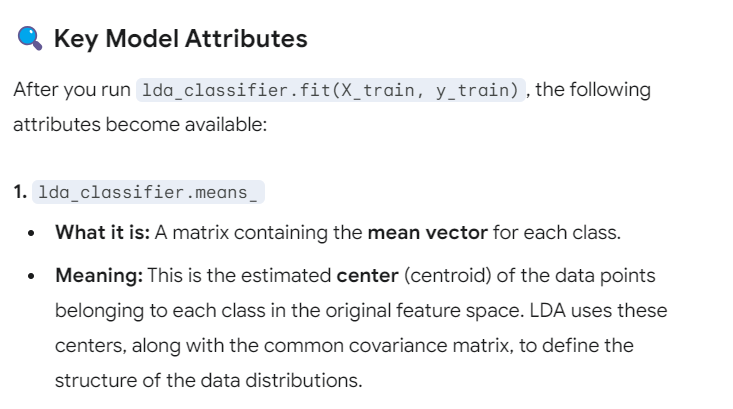

In [ ]:
lda_classifier.means_

array([[ 4.27902240e-02,  3.38940937e-02, -9.80651731e-03,
        -1.05987780e-02,  4.36659878e-03,  1.37184259e+00],
       [-3.95463511e-02, -3.13254438e-02,  5.83431953e-03,
         3.11045365e-03, -6.50887574e-04,  1.36320990e+00]])

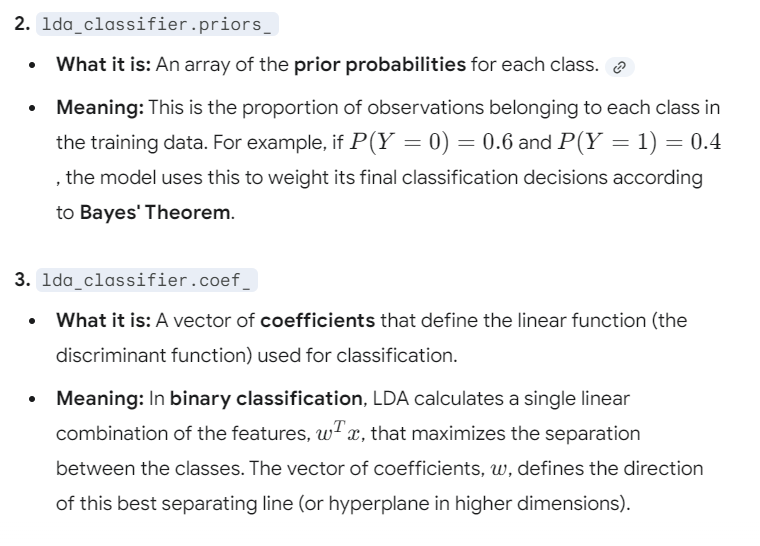

In [ ]:
lda_classifier.priors_

array([0.49198397, 0.50801603])

In [ ]:
lda_classifier.coef_

array([[-0.0540127 , -0.04567096,  0.00716777,  0.00642049, -0.00423115,
        -0.11594544]])

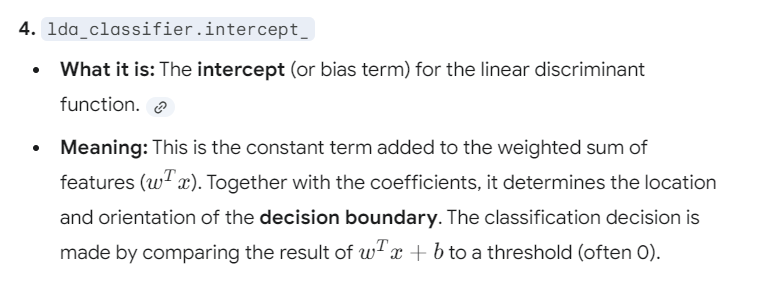

In [ ]:
lda_classifier.intercept_

array([0.19081771])

## Naive Bayes
Next, we fit a Gaussian Naive Bayes model to the `Smarket` data.

In [ ]:
# 1. Initialize the Gaussian Naive Bayes Classifier
gnb_classifier = GaussianNB()

We'll use the same test/train data from LDA.

In [ ]:
# 2. Fit the Model
# The model learns the class priors and the mean/variance of each feature per class.
gnb_classifier.fit(X_train2, y_train2)

print("### Naive Bayes Model Attributes ###")
# Print the estimated prior probabilities P(Y)
print(f"Class Priors (P(Y)): {gnb_classifier.class_prior_}")
# Print the estimated means (μ) for each feature within each class
print(f"Feature Means (μ) per class (Shape {gnb_classifier.theta_.shape}):\n{gnb_classifier.theta_}")

### Naive Bayes Model Attributes ###
Class Priors (P(Y)): [0.49198397 0.50801603]
Feature Means (μ) per class (Shape (2, 6)):
[[ 4.27902240e-02  3.38940937e-02 -9.80651731e-03 -1.05987780e-02
   4.36659878e-03  1.37184259e+00]
 [-3.95463511e-02 -3.13254438e-02  5.83431953e-03  3.11045365e-03
  -6.50887574e-04  1.36320990e+00]]


We use the fitted model to make predictions and calculate standard metrics.

In [ ]:
# 3. Make Predictions
# .predict() returns the class labels (0 or 1)
y_pred_test3 = gnb_classifier.predict(X_test2)

# .predict_proba() returns the estimated probabilities P(Y|X) for each class
y_prob_test2 = gnb_classifier.predict_proba(X_test2)

# 4. Evaluate Performance
accuracy = accuracy_score(y_test2, y_pred_test3)

print("\n--- Evaluation ---")
print(f"Test Set Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test2, y_pred_test3))
print("------------------")


--- Evaluation ---
Test Set Accuracy: 0.4563

Classification Report:
              precision    recall  f1-score   support

       False       0.43      0.77      0.55       111
        True       0.54      0.21      0.30       141

    accuracy                           0.46       252
   macro avg       0.48      0.49      0.43       252
weighted avg       0.49      0.46      0.41       252

------------------


In [ ]:
# Evaluate Performance
accuracy = accuracy_score(y_test2, y_pred_test3)
cm = confusion_matrix(y_test2, y_pred_test3)

print("\n--- Evaluation ---")
print(f"Test Set Accuracy: {accuracy:.4f}")
print("\nConfusion Matrix:")
print(cm)
print("------------------")


--- Evaluation ---
Test Set Accuracy: 0.4563

Confusion Matrix:
[[ 85  26]
 [111  30]]
------------------


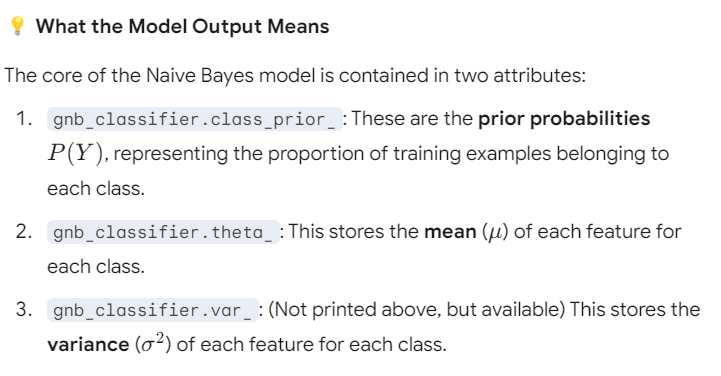

When the model makes a prediction for a new data point $X$:

It calculates the likelihood $P(X_i|Y)$ for every feature $X_i$ using the Gaussian (Normal) probability density function, based on the $\mu$ and $\sigma^2$ it calculated in the training step.

It then multiplies these likelihoods with the prior $P(Y)$ to find the unnormalized posterior $P(Y) \prod P(X_i|Y)$.

The final classification is simply the class $Y$ that yields the highest unnormalized posterior probability.